# Generate Bertoldi-Boyce dataset

## Imports

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

## Define Bertoldi-Boyce material law

In [ ]:
def material_bbF2d_torch(matconst, F):
    """2D Bertoldi-Boyce material model, which maps given deformation gradient tensors F to the strain energy density W (scalar), the 1st Piola-Kirchhoff stress tensor P (2nd order tensor) and the tangent stiffness D (4th order tensor).

    Parameters
    ----------
    matconst : torch.Tensor [3,]
        Material constants [m1, m2, kappa].
    F : torch.Tensor [B, 2, 2] or [2, 2]
        Deformation gradient tensor(s), where B is the optional batch dimension.

    Returns
    -------
    W : torch.Tensor [B] or []
        Strain energy density.
    P : torch.Tensor [B, 2, 2] or [2, 2]
        First Piola-Kirchhoff stress.
    D : torch.Tensor [B, 2, 2, 2, 2] or [2, 2, 2, 2]
        Material tangent stiffness.

    Raises
    ------
    ValueError
        If the determinant of F is negative or near zero, which indicates an invalid deformation state, or if the shape of F is not compatible with the expected dimensions.
    """

    # Change shape [2,2] -> [1,2,2] for uniform batch processing, and remember to squeeze back at the end if needed
    squeeze_output = False
    if F.ndim == 2:
        F = F.unsqueeze(0)
        squeeze_output = True

    if F.ndim != 3 or F.shape[-2:] != (2, 2):
        raise ValueError("F must have shape [B,2,2] or [2,2].")

    m1, m2, kappa = matconst[0], matconst[1], matconst[2]
    dtype = F.dtype
    device = F.device
    batch = F.shape[0]

    J = torch.linalg.det(F)
    if torch.any(J <= torch.finfo(dtype).eps):
        raise ValueError("Negative or near-zero det(F) encountered in batch")

    IF = torch.linalg.inv(F)
    B = F @ F.transpose(-1, -2)
    I1 = torch.diagonal(B, dim1=-2, dim2=-1).sum(-1) + 1.0

    W = (m1*(I1-3.0)
         +m2*(I1-3.0)**2
         -2.0*m1*torch.log(J)
         +0.5*kappa*(J-1.0)**2
    )

    P = (
        2.0 * m1 * F
        + 4.0 * m2 * (I1 - 3.0).view(batch, 1, 1) * F
        - 2.0 * m1 * IF.transpose(-1, -2)
        + kappa * (J - 1.0).view(batch, 1, 1) * J.view(batch, 1, 1) * IF.transpose(-1, -2)
    )

    id2 = torch.eye(2, dtype=dtype, device=device)
    D = torch.zeros((batch, 2, 2, 2, 2), dtype=dtype, device=device)
    for i in range(2):
        for j in range(2):
            for k in range(2):
                for l in range(2):
                    D[:, i, j, k, l] = (
                        2.0 * m1 * id2[i, k] * id2[j, l]
                        + 8.0 * m2 * F[:, i, j] * F[:, k, l]
                        + 4.0 * m2 * (I1 - 3.0) * id2[i, k] * id2[j, l]
                        + 2.0 * m1 * IF[:, l, i] * IF[:, j, k]
                        + kappa * J * J * IF[:, j, i] * IF[:, l, k]
                        + kappa * (J - 1.0) * J * IF[:, j, i] * IF[:, l, k]
                        - kappa * (J - 1.0) * J * IF[:, l, i] * IF[:, j, k]
                    )

    if squeeze_output:
        return W[0], P[0], D[0]
    return W, P, D

## Test on biaxial compression, make plots

tensor([[[1.0000, 0.0000],
         [0.0000, 1.0000]],

        [[0.9000, 0.0000],
         [0.0000, 0.9000]],

        [[0.8000, 0.0000],
         [0.0000, 0.8000]],

        [[0.7000, 0.0000],
         [0.0000, 0.7000]],

        [[0.6000, 0.0000],
         [0.0000, 0.6000]]])
Shapes -> F: torch.Size([5, 2, 2]) W: torch.Size([5]) P: torch.Size([5, 2, 2]) D: torch.Size([5, 2, 2, 2, 2])


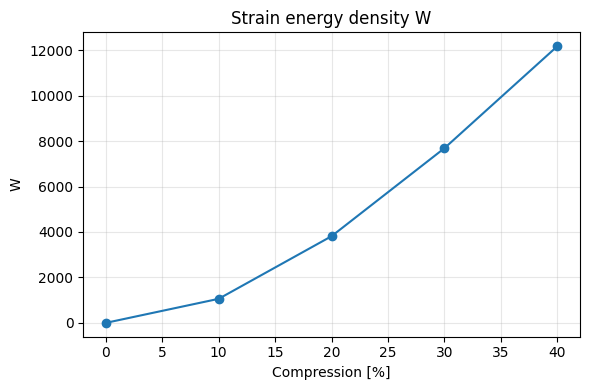

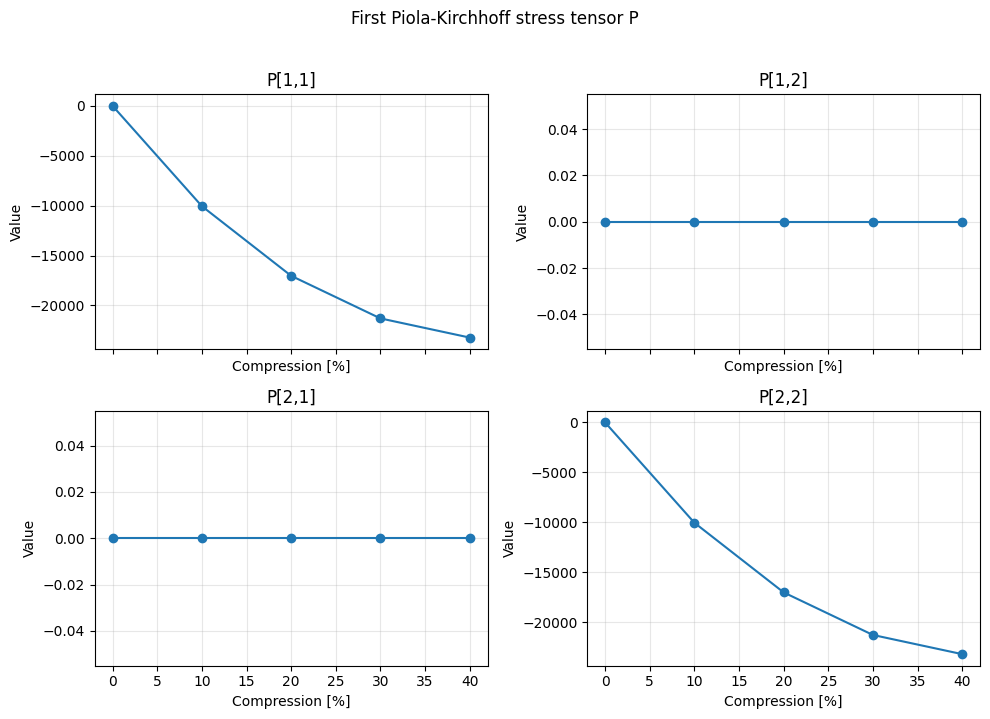

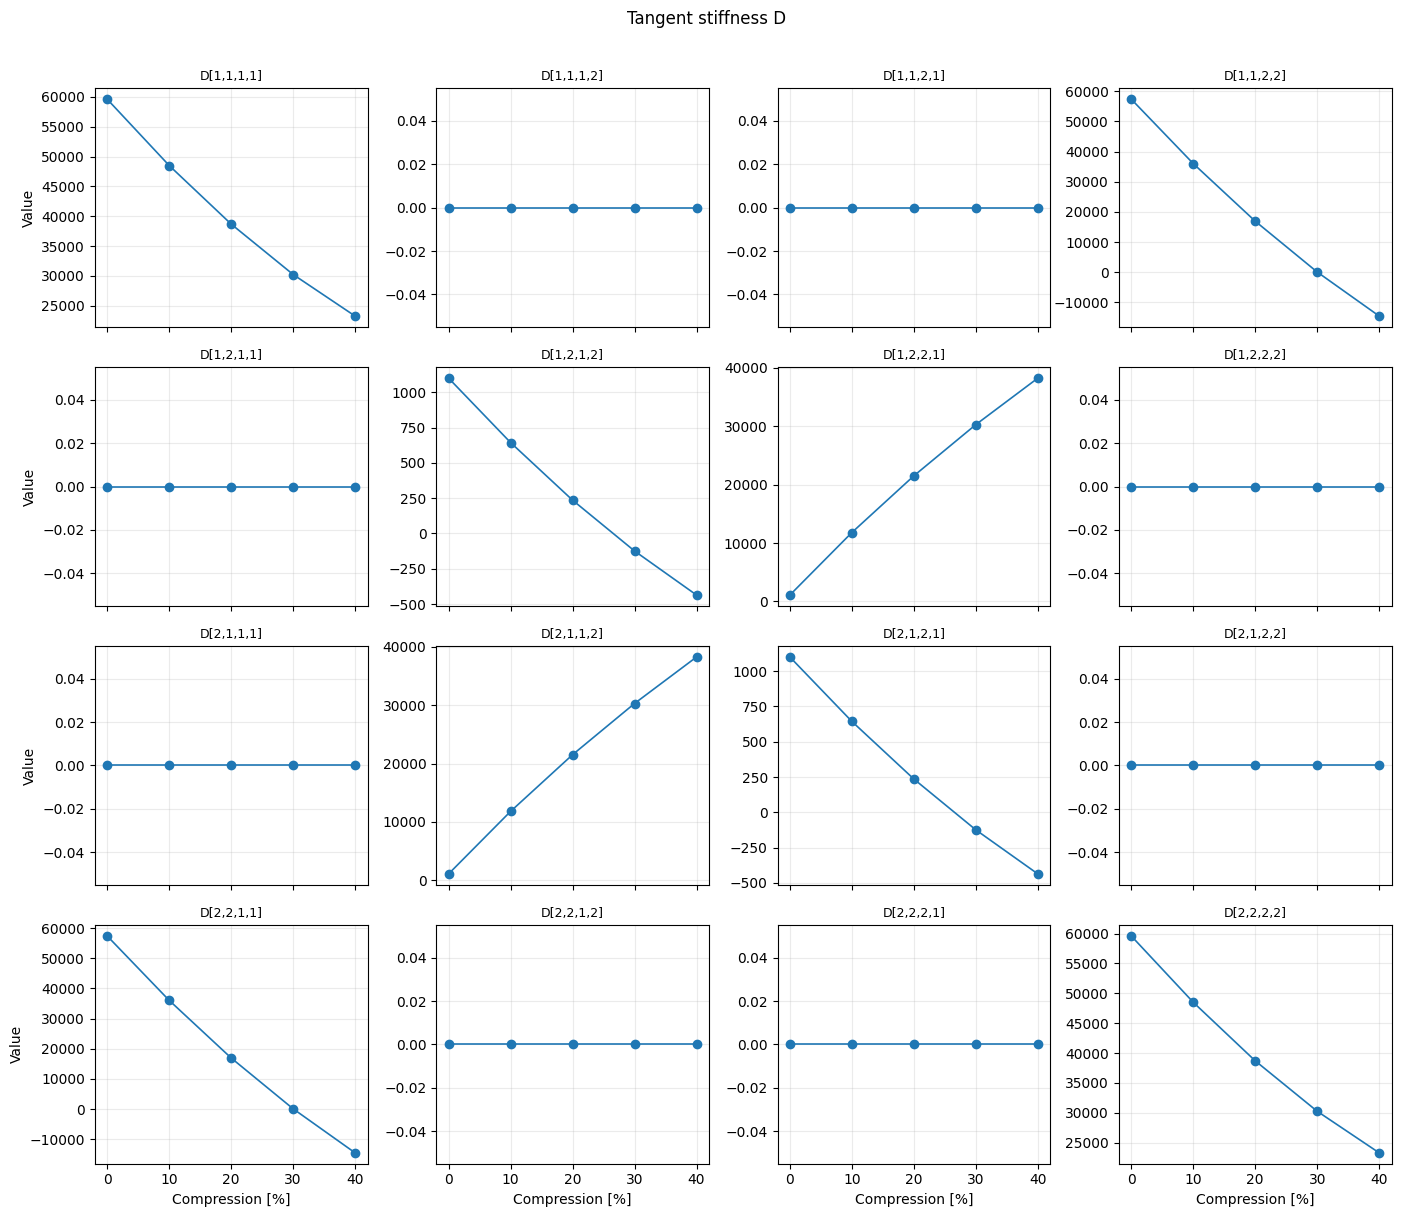

In [10]:
matconst = torch.tensor([550.0, 300.0, 55000.0])

# Biaxial compression
compr = torch.arange(0.0, 0.5, 0.1)  # 0%, 10%, ..., 40% compression
temp = torch.eye(2).unsqueeze(0).expand(len(compr), 2, 2)
temp = temp * compr.view(-1, 1, 1)
F = torch.eye(2).unsqueeze(0).expand(len(compr), 2, 2) - temp
print(F)
W, P, D = material_bbF2d_torch(matconst, F)

print("Shapes -> F:", F.shape, "W:", W.shape, "P:", P.shape, "D:", D.shape)

# Convert to NumPy for plotting
F_np = F.detach().cpu().numpy()
W_np = W.detach().cpu().numpy()
P_np = P.detach().cpu().numpy()
D_np = D.detach().cpu().numpy()

# -------------------------
# Plot 1: W
plt.figure(figsize=(6, 4))
plt.plot(compr * 100, W_np, marker='o', linewidth=1.5)
plt.xlabel('Compression [%]')
plt.ylabel('W')
plt.title('Strain energy density W')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# Plot 2: P components (2x2)
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        ax.plot(compr * 100, P_np[:, i, j], marker='o', linewidth=1.5)
        ax.set_title(f'P[{i+1},{j+1}]')
        ax.set_xlabel('Compression [%]')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
fig.suptitle('First Piola-Kirchhoff stress tensor P', y=1.02)
plt.tight_layout()
plt.show()

# -------------------------
# Plot 3: D components (4x4 grid)
fig, axes = plt.subplots(4, 4, figsize=(14, 12), sharex=True)
for i in range(2):
    for j in range(2):
        for k in range(2):
            for l in range(2):
                a = i*2 + j
                b = k*2 + l
                ax = axes[a, b]
                ax.plot(compr * 100, D_np[:, i,j,k,l], marker='o', linewidth=1.2)
                ax.set_title(f'D[{i+1},{j+1},{k+1},{l+1}]', fontsize=9)
                ax.grid(True, alpha=0.25)
                if a == 3:
                    ax.set_xlabel('Compression [%]')
                if b == 0:
                    ax.set_ylabel('Value')
fig.suptitle('Tangent stiffness D', y=1.01)
plt.tight_layout()
plt.show()

## Sample random F

In [ ]:
# Reproducibility
torch.manual_seed(42)
N = 1000  # number of samples

F_11_lims = [0.5, 1.5]  # also for F_22
F_12_lims = [0, 0.5]    # also for F_21

F = torch.rand((N, 2, 2))
F[:, 0, 0] = F_11_lims[0] + F[:, 0, 0] * (F_11_lims[1] - F_11_lims[0])
F[:, 1, 1] = F_11_lims[0] + F[:, 1, 1] * (F_11_lims[1] - F_11_lims[0])
F[:, 0, 1] = F_12_lims[0] + F[:, 0, 1] * (F_12_lims[1] - F_12_lims[0])
F[:, 1, 0] = F_12_lims[0] + F[:, 1, 0] * (F_12_lims[1] - F_12_lims[0])

print(F.shape)  # Should be [N, 2, 2]
F

torch.Size([1000, 2, 2])


tensor([[[1.3823, 0.4575],
         [0.1914, 1.4593]],

        [[0.8904, 0.3004],
         [0.1283, 1.2936]],

        [[1.4408, 0.0666],
         [0.4673, 1.0936]],

        ...,

        [[0.8520, 0.0958],
         [0.0903, 1.3475]],

        [[1.3933, 0.2155],
         [0.3266, 0.8829]],

        [[1.1060, 0.2081],
         [0.1199, 0.7896]]])

In [12]:
matconst = torch.tensor([550.0, 300.0, 55000.0])
W, P, D = material_bbF2d_torch(matconst, F)

In [13]:
print(W.shape)
print(P.shape)
print(D.shape)

torch.Size([1000])
torch.Size([1000, 2, 2])
torch.Size([1000, 2, 2, 2, 2])


In [14]:
# Save to .pt file
torch.save({'F': F, 'W': W, 'P': P, 'D': D}, 'BertoldiBoyce_dataset.pt')